# Lab 5 Report:
## Create Arthur Conan Doyle AI with RNN

### Name: Josh Lando

In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import torch
import wandb
from torch.distributions import Categorical

In [ ]:
from IPython.display import Image # For displaying images in colab jupyter cell

In [ ]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [84]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Prepare Data

In [ ]:
# First n-characters to use for training
data_size_to_train = 10000

# Load the Shakespeare data up to data_size_to_train
data = open('/content/drive/MyDrive/Colab Notebooks/sherlock.txt', 'r').read()[:data_size_to_train]

# Find the unique characters within the training data
characters = sorted(list(set(data)))

# total number of characters in the training data and number of unique characters
data_size, vocab_size = len(data), len(characters)

print("Data has {} characters, {} unique".format(data_size, vocab_size))

Data has 10000 characters, 65 unique


In [ ]:
# Use Python Dictionary to map the characters to numbers and vice versa

character_to_num = { ch:i for i,ch in enumerate(characters) }
num_to_character = { i:ch for i,ch in enumerate(characters) }

print(character_to_num)

{'\n': 0, ' ': 1, '!': 2, '"': 3, "'": 4, '(': 5, ')': 6, ',': 7, '-': 8, '.': 9, '1': 10, '7': 11, '8': 12, ';': 13, '?': 14, 'A': 15, 'B': 16, 'C': 17, 'D': 18, 'E': 19, 'F': 20, 'G': 21, 'H': 22, 'I': 23, 'J': 24, 'K': 25, 'L': 26, 'M': 27, 'N': 28, 'O': 29, 'P': 30, 'Q': 31, 'R': 32, 'S': 33, 'T': 34, 'U': 35, 'V': 36, 'W': 37, 'Y': 38, 'a': 39, 'b': 40, 'c': 41, 'd': 42, 'e': 43, 'f': 44, 'g': 45, 'h': 46, 'i': 47, 'j': 48, 'k': 49, 'l': 50, 'm': 51, 'n': 52, 'o': 53, 'p': 54, 'q': 55, 'r': 56, 's': 57, 't': 58, 'u': 59, 'v': 60, 'w': 61, 'x': 62, 'y': 63, 'z': 64}


In [ ]:
# Use the character_to_num dictionary to map each character in the training dataset to a number

data = list(data)

for i, ch in enumerate(data):
    data[i] = character_to_num[ch]

print(data[:10])

[0, 1, 1, 1, 1, 1, 1, 1, 1, 1]


# Define Sweep

In [ ]:
import pprint

sweep_config = {
    'method': 'bayes'
    }

metric = {
    'name': 'val_loss',
    'goal': 'minimize'
    }

sweep_config['metric'] = metric

parameters_dict = {
  'optimizer': {
      'value': 'adamw'
      },
  'learning_rate': {
        'distribution': 'uniform',
        'min': 1e-4,
        'max': 1e-2
      },
  'epochs': {
        'value': 3
      },
  'training_sequence_length': {
        'value': 512
      },
  'fc_layer_size': {
      'value': 512
      },
  'num_layers': {
        'value': 3
      },
  'dropout': {
        'values': [0, 0.1, 0.3, 0.4, 0.5, 0.6, 0.7]
      },
  'weight_decay': {
        'distribution': 'uniform',
        'min': 0,
        'max': 0.3
      }
  }

sweep_config['parameters'] = parameters_dict

pprint.pprint(sweep_config)

{'method': 'bayes',
 'metric': {'goal': 'minimize', 'name': 'val_loss'},
 'parameters': {'dropout': {'values': [0, 0.1, 0.3, 0.4, 0.5, 0.6, 0.7]},
                'epochs': {'value': 3},
                'fc_layer_size': {'value': 512},
                'learning_rate': {'distribution': 'uniform',
                                  'max': 0.01,
                                  'min': 0.0001},
                'num_layers': {'value': 3},
                'optimizer': {'value': 'adamw'},
                'training_sequence_length': {'value': 512},
                'weight_decay': {'distribution': 'uniform',
                                 'max': 0.3,
                                 'min': 0}}}


In [ ]:
sweep_id = wandb.sweep(sweep_config, project="phys417-lab5")

Create sweep with ID: nv54sn3d
Sweep URL: https://wandb.ai/b6k4pq9yqk-university-of-washington/phys417-lab5/sweeps/nv54sn3d


## Define Model

In [ ]:
class CharRNN(torch.nn.Module):

    def __init__(self, num_embeddings, embedding_dim, input_size, hidden_size, num_layers, output_size, dropout):

        super(CharRNN, self).__init__()

        # Define embedding layer
        # num_embeddings = number of unique characters
        # embedding_dim = size of a vector that encodes each character
        self.embedding = torch.nn.Embedding(num_embeddings, embedding_dim)

        # Define vanilla RNN cell
        # num_layers = Number of RNN cells to be stacked for deep-RNN
        # nonlinearity = Activation function to use
        self.rnn = torch.nn.RNN(input_size=input_size, hidden_size=hidden_size,
                                num_layers=num_layers,
                                nonlinearity = 'tanh',
                                dropout=dropout)

        # decoder layer that takes hidden states as inputs and output probabilities for each character
        # output_size = number of unique characters
        self.decoder = torch.nn.Linear(hidden_size, output_size)

    def forward(self, input_seq, hidden_state):

        # Forward pass input sequence to embedding layer
        embedding = self.embedding(input_seq)

        # RNN cell takes output of embedding layer + previous hidden state as inputs
        output, hidden_state = self.rnn(embedding, hidden_state)

        # Forward pass the RNN cell output to decoder to get the probabilities
        output = self.decoder(output)

        # hidden states need to be detached from computation graph to be re-used as input
        return output, hidden_state.detach()

## Define Hyperparameters

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Fix random seed
torch.manual_seed(25)

# Derfine model size
embedding_dim = 100
input_size = 100

def train(config=None):
    # Initialize a new wandb run
    with wandb.init(config=config):
        # If called by wandb.agent, as below,
        # this config will be set by Sweep Controller
        config = wandb.config

        rnn = CharRNN(num_embeddings = vocab_size, embedding_dim = embedding_dim,
              input_size = input_size, hidden_size = config.fc_layer_size, num_layers = config.num_layers,
              output_size = vocab_size, dropout = config.dropout)

        rnn.to(device)

        optimizer = build_optimizer(rnn, config.optimizer, config.learning_rate, config.weight_decay)

        loss_fn = torch.nn.CrossEntropyLoss()

        # Fetch global data
        global data
        # Safely extract list whether it is a tensor or already a list
        data_list = data.tolist() if isinstance(data, torch.Tensor) else data

        # Convert training data into torch tensor and make it into vertical orientation (N, 1)
        tensor_data = torch.unsqueeze(torch.tensor(data_list), dim = 1).to(device)

        for epoch in range(config.epochs):
            train_epoch(rnn, optimizer, config.training_sequence_length, loss_fn, tensor_data)
            avg_val_loss = validate_epoch(rnn, loss_fn, tensor_data)
            wandb.log({"val_loss": avg_val_loss, "epoch": epoch})

In [ ]:
def build_optimizer(network, optimizer, learning_rate, weight_decay):
    if optimizer == "sgd":
        optimizer = torch.optim.SGD(network.parameters(),
                              lr=learning_rate, momentum=0.9, weight_decay=weight_decay)
    elif optimizer == "adamw":
        optimizer = torch.optim.AdamW(network.parameters(),
                               lr=learning_rate, weight_decay=weight_decay)
    return optimizer

## Train Model

In [63]:
def train_epoch(network, optimizer, training_sequence_len, loss_fn, data, max_len = 10000):

    # Set the network to training mode
    network.train()

    # Randomly select a starting character from first 100 characters in training set
    character_loc = np.random.randint(100)

    # initialize initial hiddens state as None
    hidden_state = None

    while character_loc + training_sequence_len + 1 < max_len: # loop continues until target_seq reaches end of the data

        # Define input/target sequence
        input_seq = data[character_loc : character_loc + training_sequence_len]
        target_seq = data[character_loc + 1 : character_loc + training_sequence_len + 1]

        # Pass input sequence and hidden_state to RNN
        output, hidden_state = network(input_seq, hidden_state)

        # Compute loss between RNN output sequence vs target sequence
        # torch.squeeze removes the column dimension and make them into horizontal orientation
        loss = loss_fn(torch.squeeze(output), torch.squeeze(target_seq))

        # wandb.log({"train loss": loss.item()})

        # Empty gradient buffer -> backpropagation -> update network
        optimizer.zero_grad()
        loss.backward()

        # Prevent exploding gradients by clipping the gradients
        torch.nn.utils.clip_grad_norm_(network.parameters(), max_norm=5.0)

        optimizer.step()

        # Update starting character for next sequence
        character_loc += training_sequence_len



def validate_epoch(network, loss_fn, data, max_len = 10000, validation_sequence_len = 200):
    # Set the network to evaluation mode
    network.eval()

    # Randomly select a starting character from first 100 characters in validation set
    character_loc = np.random.randint(100)

    # initialize initial hiddens state as None
    hidden_state = None
    epoch_validation_losses = [] # To collect losses for this validation epoch

    with torch.no_grad(): # Disable gradient calculations for validation
        while character_loc + validation_sequence_len + 1 < max_len: # loop continues until target_seq reaches end of the data

            # Define input/target sequence
            input_seq = data[character_loc : character_loc + validation_sequence_len]
            target_seq = data[character_loc + 1 : character_loc + validation_sequence_len + 1]

            # Pass input sequence and hidden_state to RNN
            output, hidden_state = network(input_seq, hidden_state)

            # Compute loss between RNN output sequence vs target sequence
            # torch.squeeze removes the column dimension and make them into horizontal orientation
            loss = loss_fn(torch.squeeze(output), torch.squeeze(target_seq))

            epoch_validation_losses.append(loss.item())

            # Update starting character for next sequence
            character_loc += validation_sequence_len

    return np.mean(epoch_validation_losses) if epoch_validation_losses else 0.0

In [ ]:
wandb.agent(sweep_id, train, count=100)

wandb: Agent Starting Run: yfm0adal with config:
wandb: 	dropout: 0.5
wandb: 	epochs: 3
wandb: 	fc_layer_size: 512
wandb: 	learning_rate: 0.00975255587050124
wandb: 	num_layers: 3
wandb: 	optimizer: adamw
wandb: 	training_sequence_length: 512
wandb: 	weight_decay: 0.13232516582315915
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▅█
train loss,▁▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▆▄▂▂▂▂▂▂▂▂
val_loss,▁▁█
epoch,2
train loss,4.31619
val_loss,35.61685


wandb: Agent Starting Run: kyerz7c1 with config:
wandb: 	dropout: 0
wandb: 	epochs: 3
wandb: 	fc_layer_size: 512
wandb: 	learning_rate: 0.00801483143890161
wandb: 	num_layers: 3
wandb: 	optimizer: adamw
wandb: 	training_sequence_length: 512
wandb: 	weight_decay: 0.03242765531888246
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▅█
train loss,▂▂█▆▆▄▄▄▃▃▃▃▃▂▃▃▁▂▁▃▂▂▂▂▂▂▂▂▁▁▂▂▁▂▂▁▁▂▁▁
val_loss,█▄▁
epoch,2
train loss,3.94573
val_loss,3.88927


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 475zmvou with config:
wandb: 	dropout: 0.1
wandb: 	epochs: 3
wandb: 	fc_layer_size: 512
wandb: 	learning_rate: 0.0059464083793815126
wandb: 	num_layers: 3
wandb: 	optimizer: adamw
wandb: 	training_sequence_length: 512
wandb: 	weight_decay: 0.07579108274054416
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


...

epoch,▁▅█
train loss,▂▆▁▄▃▂▂▂▂▂▂▂▂▂▂▂▃▂▂▂▂▂▂▂▂▁▁▁▁▁█▅▄▄▄▄▄▄▄▄
val_loss,▂▁█
epoch,2
train loss,4.02683
val_loss,3.86933


wandb: Agent Starting Run: oqu2dwqa with config:
wandb: 	dropout: 0.6
wandb: 	epochs: 3
wandb: 	fc_layer_size: 512
wandb: 	learning_rate: 0.008155774446977907
wandb: 	num_layers: 3
wandb: 	optimizer: adamw
wandb: 	training_sequence_length: 512
wandb: 	weight_decay: 0.06399413626074789
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▅█
train loss,▃▂█▆▄▄▄▄▄▄▄▄▃▄▄▃▄▃▂▂▂▂▂▁▁▂▃▂▁▁▁▁▂▂▂▁▁▂▂▁
val_loss,▂▁█
epoch,2
train loss,3.2794
val_loss,8.0628


wandb: Agent Starting Run: a9clmkf3 with config:
wandb: 	dropout: 0.6
wandb: 	epochs: 3
wandb: 	fc_layer_size: 512
wandb: 	learning_rate: 0.00620505769217716
wandb: 	num_layers: 3
wandb: 	optimizer: adamw
wandb: 	training_sequence_length: 512
wandb: 	weight_decay: 0.09710860276673752
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


epoch,▁▅█
train loss,▁█▃▂▂▂▂▂▂▂▃▂▂▃▂▁▃▃▃▂▂▂▃▂▃▂▃▃▃▃▄▃▂▂▂▂▂▂▂▂
val_loss,██▁
epoch,2
train loss,3.21887
val_loss,3.31823


# Train Final

In [76]:
config = {
    'optimizer': 'adamw',
    'learning_rate': 0.00069104416484892,
    'epochs': 50,
    'training_sequence_length': 512,
    'fc_layer_size': 512,
    'num_layers': 3,
    'dropout': 0.1,
    'weight_decay': 0.022107379060116103
}

rnn = CharRNN(num_embeddings = vocab_size, embedding_dim = embedding_dim,
      input_size = input_size, hidden_size = config['fc_layer_size'], num_layers = config['num_layers'],
      output_size = vocab_size, dropout = config['dropout'])

rnn.to(device)

optimizer = build_optimizer(rnn, config['optimizer'], config['learning_rate'], config['weight_decay'])

loss_fn = torch.nn.CrossEntropyLoss()

data_list = data.tolist() if isinstance(data, torch.Tensor) else data

# Convert training data into torch tensor and make it into vertical orientation (N, 1)
tensor_data = torch.unsqueeze(torch.tensor(data_list), dim = 1).to(device)

train_loss_list = []

for epoch in range(config['epochs']):
    train_epoch(rnn, optimizer, config['training_sequence_length'], loss_fn, tensor_data)
    avg_val_loss = validate_epoch(rnn, loss_fn, tensor_data)
    train_loss_list.append(avg_val_loss)
    print(f"Epoch {epoch} - Validation Loss: {avg_val_loss:.4f}")

Epoch 0 - Validation Loss: 3.1819
Epoch 1 - Validation Loss: 2.5791
Epoch 2 - Validation Loss: 2.3576
Epoch 3 - Validation Loss: 2.1420
Epoch 4 - Validation Loss: 2.0185
Epoch 5 - Validation Loss: 1.9642
Epoch 6 - Validation Loss: 1.8569
Epoch 7 - Validation Loss: 1.7749
Epoch 8 - Validation Loss: 1.7103
Epoch 9 - Validation Loss: 1.6011
Epoch 10 - Validation Loss: 1.5632
Epoch 11 - Validation Loss: 1.4655
Epoch 12 - Validation Loss: 1.3867
Epoch 13 - Validation Loss: 1.2977
Epoch 14 - Validation Loss: 1.2068
Epoch 15 - Validation Loss: 1.1306
Epoch 16 - Validation Loss: 1.0537
Epoch 17 - Validation Loss: 0.9616
Epoch 18 - Validation Loss: 0.9009
Epoch 19 - Validation Loss: 0.8937
Epoch 20 - Validation Loss: 0.8169
Epoch 21 - Validation Loss: 0.7354
Epoch 22 - Validation Loss: 0.6252
Epoch 23 - Validation Loss: 0.5757
Epoch 24 - Validation Loss: 0.5190
Epoch 25 - Validation Loss: 0.4570
Epoch 26 - Validation Loss: 0.4043
Epoch 27 - Validation Loss: 0.3452
Epoch 28 - Validation Loss: 0.

## Visualize & Evaluate Model

In [77]:
# Print a validation text sequence that most closely resembles Sherlock Holmes style
validation_sequence_len = 20000
character_loc = np.random.randint(100)

# initialize initial hiddens state as None
hidden_state = None

# Convert the single input character into a 2D tensor (seq_len=1, batch=1) and move to device
input_seq = torch.tensor([[data[character_loc]]]).to(device)

rnn.eval()

with torch.no_grad():

    while character_loc < validation_sequence_len: # Loop continues until RNN generated sequence is in desired length

        # Pass validation sequence to RNN
        # Note that RNN now uses its previous output character as input
        output, hidden_state = rnn(input_seq, hidden_state)

        # Take the softmax of the decoder output to get the probabilities of predicted characters
        output = torch.nn.functional.softmax(torch.squeeze(output), dim=0)
        # Use the  probabilities to sample the output character
        character_distribution = torch.distributions.Categorical(output)
        character_num = character_distribution.sample()

        # Convert the character number selected from sampling to actual character and print
        print(num_to_character[character_num.item()], end='')

        # Update the input_seq so that it's using the output of the RNN as new input
        input_seq[0][0] = character_num.item()

        # Update the character location
        character_loc += 1

Inderirsted to Nad have had already
 improved so far as to be able to walk about the wards, and even to
 bask a little upon the verandah, when I was struck down by enteric
 fever, that curse of our Indicale faz
       The Adventure of the Lion's Mane
       The Adventure of the Retired Colourman











                                                                                  (ok Ligh                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            TBe CLook I
                                                                                  

In [67]:
# Import seaborn for prettier plot
import seaborn as sns

sns.set(style = 'whitegrid', font_scale = 2.5)

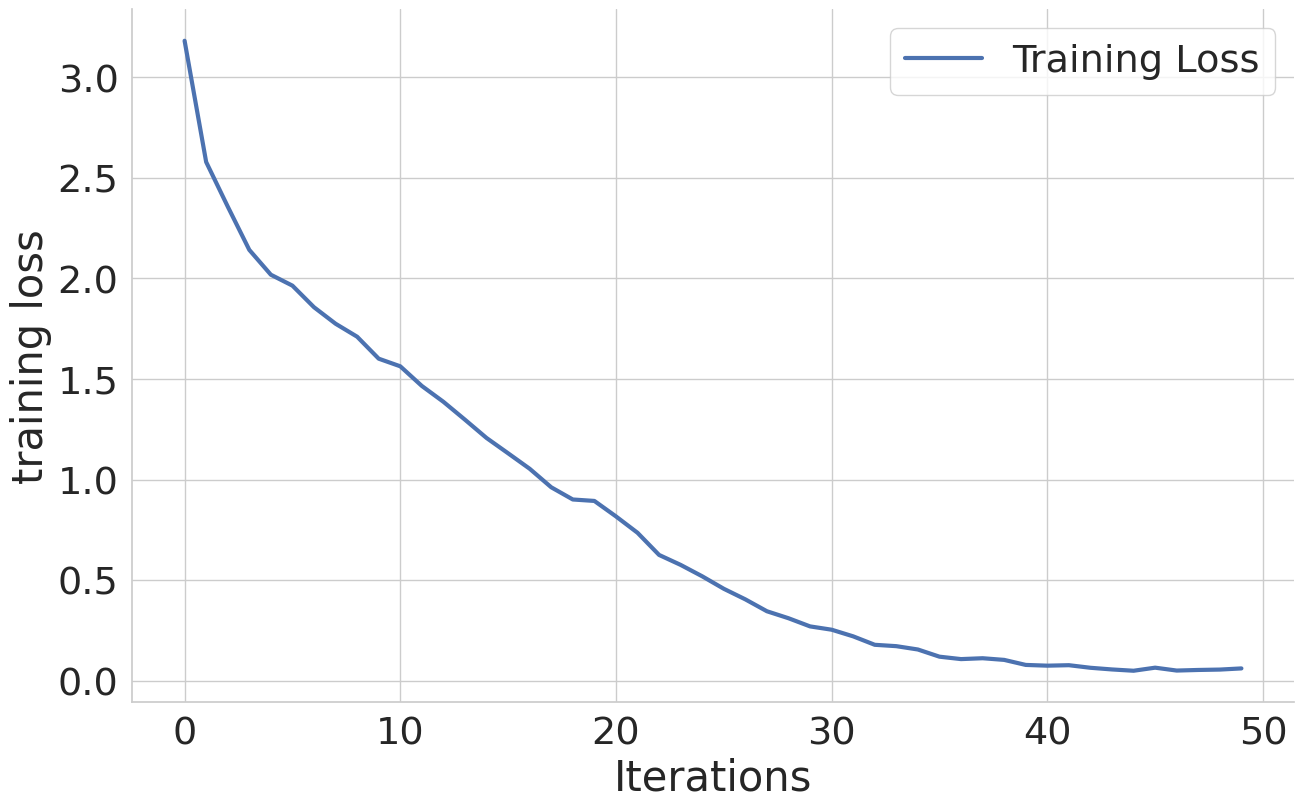

In [79]:
# Plot the training loss and rolling mean training loss with respect to iterations
# Feel free to change the window size
plt.figure(figsize = (15, 9))

plt.plot(train_loss_list, linewidth = 3, label = 'Training Loss')
# plt.plot(np.convolve(train_loss_list, np.ones(100), 'valid') / 100,
#         linewidth = 3, label = 'Rolling Averaged Training Loss')
plt.ylabel("training loss")
plt.xlabel("Iterations")
plt.legend()
sns.despine()